# ECPM Model Analysis — Weekday / Weekend Split

Three fitting methods, each run **separately for weekdays and weekends**:

| # | Model | Method |
|---|-------|--------|
| A | Multiplicative ECPM | `scipy.optimize.curve_fit` |
| B | Additive ECPM | `scipy.optimize.curve_fit` |
| C | Additive ECPM | `sklearn.linear_model.Ridge` |

Change-point temperatures **Tc** and **Th** are loaded from `cp_params.csv` — one row per *(year, day_type)* combination.

### Model Equations

**Multiplicative ECPM:**
$$E = E_b + E_c + E_h$$
$$E_c = c_c \cdot (T_{ext} - T_c)^+ \cdot (T_{ext} - T_{int})^+$$
$$E_h = c_h \cdot (T_h - T_{ext})^+ \cdot (T_{int} - T_{ext})^+$$

**Additive ECPM:**
$$\theta(x) = 1 \text{ if } x > 0, \quad 0 \text{ otherwise}$$
$$E = E_b + E_c + E_h$$
$$E_c = c_{c1}(T_{ext} - T_c)^+ + c_{c2}(T_{ext} - T_{int})^+ \cdot \theta(T_{ext} - T_c)$$
$$E_h = c_{h1}(T_h - T_{ext})^+ + c_{h2}(T_{int} - T_{ext})^+ \cdot \theta(T_h - T_{ext})$$

> **Note on $c_{c2} = 0$:** For some building-year combinations, $c_{c2}$ is correctly estimated as zero. This occurs when $T_{int} > T_{ext}$ in the majority of cooling-zone days (tight HVAC control keeps indoor temperature nearly constant), making the feature $(T_{ext} - T_{int})^+$ inactive. This is a valid sparse result, not a fitting error.

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path

DATA_DIR     = Path("../Prepared_Data")
CPM_PARAM = Path("../CPM_Results/AllYears_Preprocessed_Method1")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

# Colour scheme: weekday = blue family, weekend = orange family
COLORS = {
    ('weekday', 'mult'):  '#2271B5',
    ('weekday', 'cf'):    '#4AA8D8',
    ('weekday', 'ridge'): '#1B5E8A',
    ('weekend', 'mult'):  '#E9672A',
    ('weekend', 'cf'):    '#F5AE3C',
    ('weekend', 'ridge'): '#B34A18',
    'actual_wd': '#888888',
    'actual_we': '#BBBBBB',
}

print('All packages loaded.')

All packages loaded.


## 1 · Load data

In [2]:
# ── File paths ─────────────────────────────────────────────────────────────
ENERGY_CSV    = DATA_DIR / 'KEPCO_AllYears_Preprocessed_Method1.csv'
CP_PARAMS_CSV = CPM_PARAM / 'KEPCO_Yearly_CPM_Parameters.csv'   # must have columns: year, day_type, Tc, Th, alpha

# ── Load and clean energy data ──────────────────────────────────────────────
df = pd.read_csv(ENERGY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.dropna(subset=['electricity_kWh', 'temp_external', 'temp_internal', 'is_weekend'])
df = df.sort_values('datetime').reset_index(drop=True)
df['is_weekend'] = df['is_weekend'].astype(int)
df['day_type']   = df['is_weekend'].map({0: 'weekday', 1: 'weekend'})

# ── Derive floor area (m²) to convert CPM alpha (Wh/m²) → Eb (kWh) ─────────
floor_area_m2 = (df['electricity_kWh'] * 1000 / df['EUI_Wh_m2']).median()

print(f'Total rows : {len(df)}')
print(f'Weekdays   : {(df["is_weekend"]==0).sum()}')
print(f'Weekends   : {(df["is_weekend"]==1).sum()}')
print(f'Date range : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Years      : {sorted(df["year"].unique())}')
print(f'Floor area : {floor_area_m2:.1f} m²  (derived from electricity_kWh / EUI_Wh_m2)')
df.head(3)

Total rows : 802
Weekdays   : 631
Weekends   : 171
Date range : 2020-04-17 → 2025-08-25
Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Floor area : 5381.0 m²  (derived from electricity_kWh / EUI_Wh_m2)


,datetime,year,is_weekend,electricity_kWh,temp_external,temp_internal,EUI_Wh_m2,day_type
0,2020-04-17,2020,0,54.583333,12.902246,21.724062,10.143678,weekday
1,2020-04-19,2020,1,28.916667,12.943029,19.284050,5.373826,weekend
2,2020-04-21,2020,0,57.343750,8.183979,20.794250,10.656669,weekday


In [3]:
cp = pd.read_csv(CP_PARAMS_CSV)

# Normalize 'Year' → 'year' (case-insensitive)
for c in cp.columns:
    if c.lower() == 'year' and c != 'year':
        cp = cp.rename(columns={c: 'year'})
        break

# Normalize tau_c/tau_h → Tc/Th
if 'Tc' not in cp.columns and 'tau_c' in cp.columns:
    cp = cp.rename(columns={'tau_c': 'Tc', 'tau_h': 'Th'})

# Normalize day_type: 'weekdays' → 'weekday', 'weekends' → 'weekend'
cp['day_type'] = cp['day_type'].str.lower().str.strip().str.rstrip('s')

# Ensure year is string
cp['year'] = cp['year'].astype(str)

print('cp_params loaded:')
print(cp[['year', 'day_type', 'Tc', 'Th', 'alpha']].to_string(index=False))

cp_params loaded:
year day_type        Tc        Th    alpha
2020  weekday 19.850984 15.717406 8.088062
2021  weekday 19.279113 16.050441 8.088170
2022  weekday 29.991323 18.000000 7.095364
2023  weekday 19.000000 17.471785 8.558551
2024  weekday 19.000000 17.999995 8.176958
2025  weekday 19.000000 14.920921 9.222155
2020  weekend 27.822258 18.000000 5.058577
2021  weekend 24.571549 17.596374 4.881578
2022  weekend 29.017247  9.541994 4.732380
2023  weekend 30.000000 18.000000 5.738834
2024  weekend 19.000000  9.092649 5.482652
2025  weekend 23.347154 12.945042 5.974603


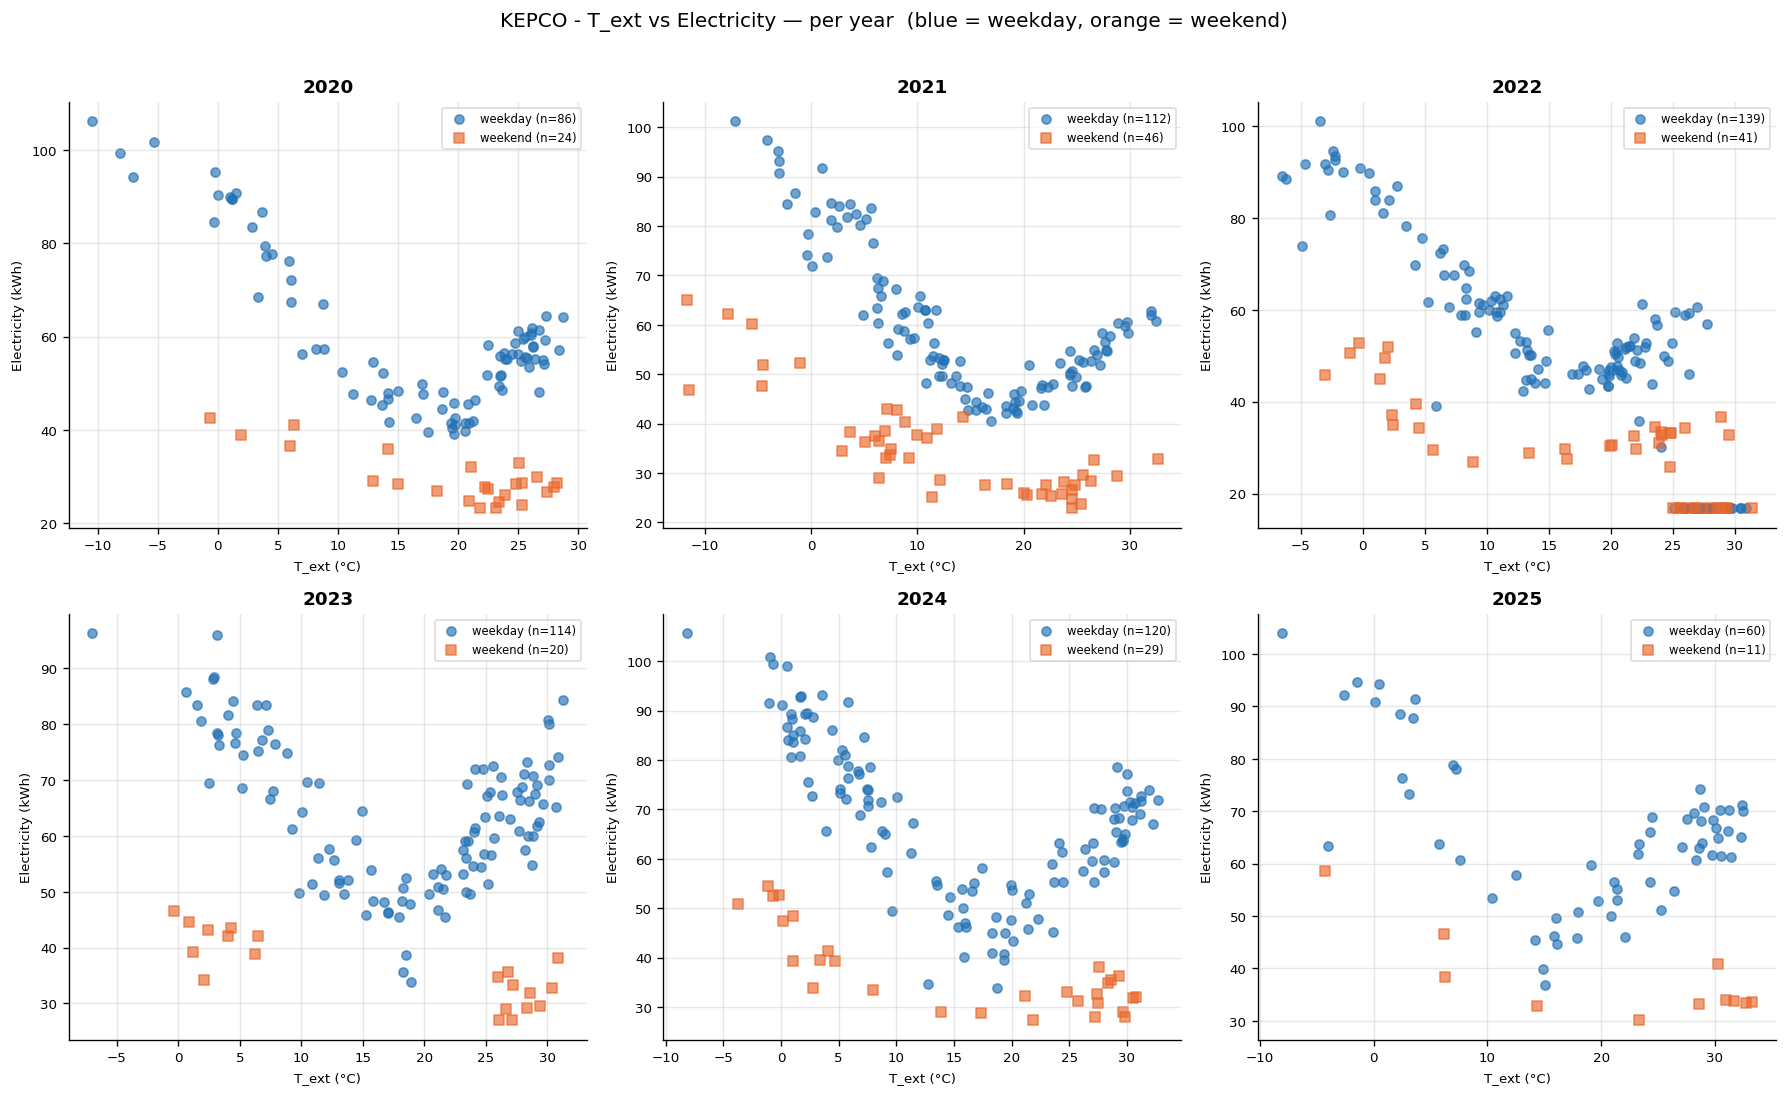


Data summary per year / day_type:


n  T_ext_min  T_ext_max  kWh_mean  kWh_std
year day_type                                              
2020 weekday    86      -10.4       28.7      59.8     16.6
     weekend    24       -0.7       28.2      29.8      5.5
2021 weekday   112       -7.2       32.5      59.9     14.8
     weekend    46      -11.7       32.6      35.3     10.4
2022 weekday   139       -6.5       31.0      51.2     22.0
     weekend    41       -3.1       31.4      30.1     10.9
2023 weekday   114       -7.0       31.3      63.6     12.9
     weekend    20       -0.4       30.8      36.1      6.2
2024 weekday   120       -8.2       32.7      67.6     15.8
     weekend    29       -3.7       30.8      36.9      8.3
2025 weekday    60       -8.1       32.4      65.1     14.5
     weekend    11       -4.2       33.3      37.8      8.3

In [4]:
# ── EDA: Per-year scatter — T_ext vs Energy (weekday / weekend) ──────────────
years  = sorted(df['year'].unique())
ncols  = 3
nrows  = -(-len(years) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

for ax, yr in zip(axes, years):
    for dt, col, mkr in [('weekday', '#2271B5', 'o'), ('weekend', '#E9672A', 's')]:
        sub = df[(df['year'] == yr) & (df['day_type'] == dt)]
        if sub.empty:
            continue
        ax.scatter(sub['temp_external'], sub['electricity_kWh'],
                   color=col, marker=mkr, s=30, alpha=0.65, label=f'{dt} (n={len(sub)})')

    ax.set_title(f'{yr}', fontsize=11, fontweight='bold')
    ax.set_xlabel('T_ext (°C)', fontsize=8)
    ax.set_ylabel('Electricity (kWh)', fontsize=8)
    ax.legend(fontsize=7, framealpha=0.7)
    ax.tick_params(labelsize=8)

for ax in axes[len(years):]:
    ax.set_visible(False)

fig.suptitle('KEPCO - T_ext vs Electricity — per year  (blue = weekday, orange = weekend)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('eda_scatter_per_year.png', bbox_inches='tight')
plt.show()

# ── Summary count table ───────────────────────────────────────────────────────
summary = (df.groupby(['year','day_type'])
             .agg(n=('electricity_kWh','count'),
                  T_ext_min=('temp_external','min'),
                  T_ext_max=('temp_external','max'),
                  kWh_mean=('electricity_kWh','mean'),
                  kWh_std=('electricity_kWh','std'))
             .round(1))
print('\nData summary per year / day_type:')
display(summary)


### T_int vs T_ext Correlation

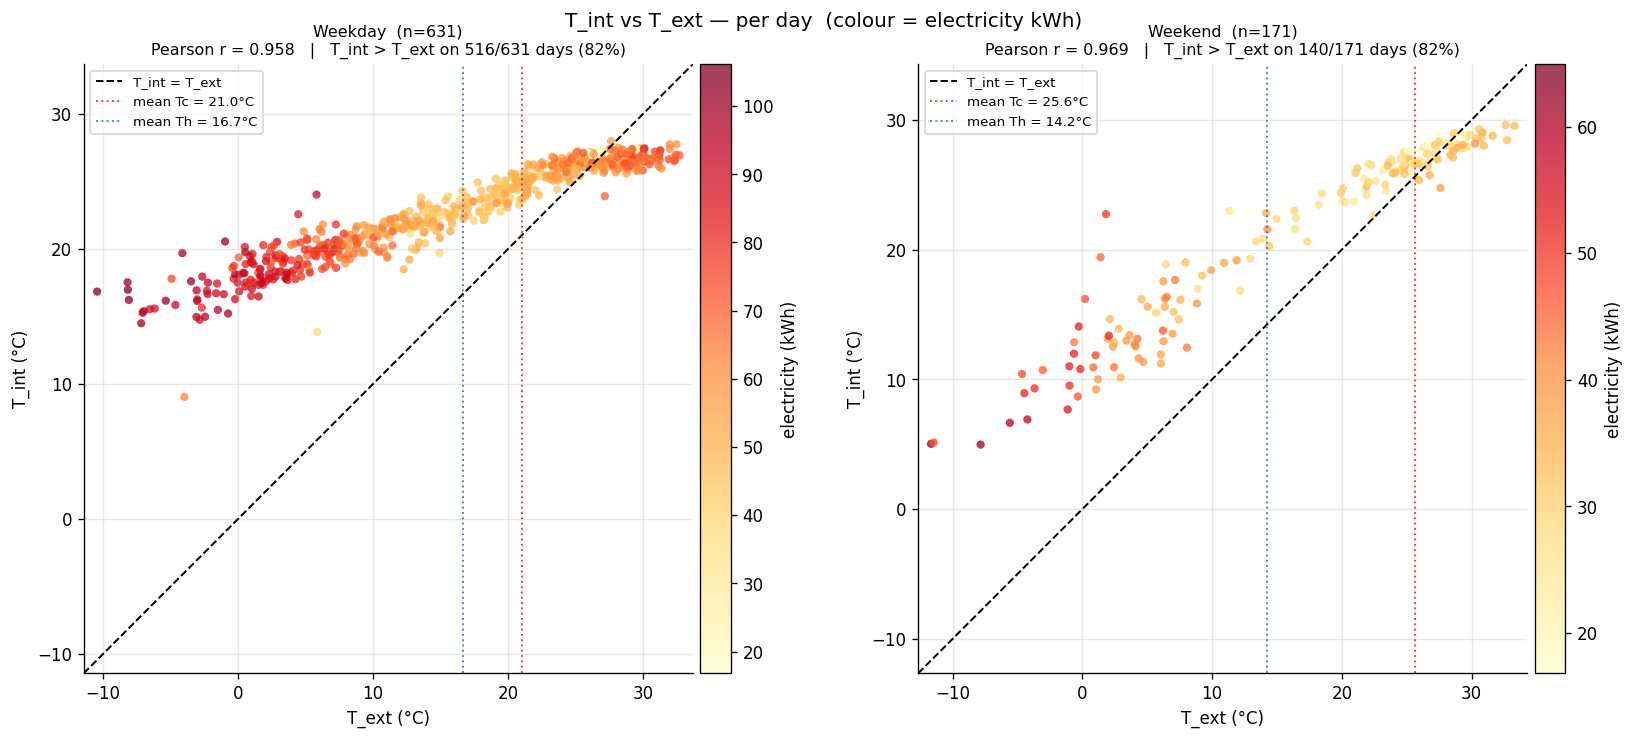

Saved: tint_vs_text_correlation.png

Per-year: Pearson r(T_ext, T_int) and % days where T_int > T_ext


,year,day_type,n,pearson_r,n_Tint_gt_Text,pct_Tint_gt_Text
0,2020,weekday,86,0.974,77,89.5
1,2020,weekend,24,0.960,23,95.8
2,2021,weekday,112,0.973,99,88.4
3,2021,weekend,46,0.976,43,93.5
4,2022,weekday,139,0.966,125,89.9
5,2022,weekend,41,0.949,35,85.4
6,2023,weekday,114,0.966,89,78.1
7,2023,weekend,20,0.990,14,70.0
8,2024,weekday,120,0.961,88,73.3
9,2024,weekend,29,0.976,20,69.0


In [5]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('T_int vs T_ext — per day  (colour = electricity kWh)', fontsize=12)

for ax, day_type, base_col in zip(axes,
                                   ['weekday', 'weekend'],
                                   ['#2271B5', '#E9672A']):
    sub = df[df['day_type'] == day_type]

    sc = ax.scatter(sub['temp_external'], sub['temp_internal'],
                    c=sub['electricity_kWh'], cmap='YlOrRd',
                    s=25, alpha=0.75, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='electricity (kWh)', pad=0.01)

    # y = x diagonal
    lim_min = min(sub['temp_external'].min(), sub['temp_internal'].min()) - 1
    lim_max = max(sub['temp_external'].max(), sub['temp_internal'].max()) + 1
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            'k--', lw=1.2, label='T_int = T_ext')

    # Tc / Th bands from cp_params
    cp_dt = cp[cp['day_type'] == day_type]
    tc_mean = cp_dt['Tc'].mean()
    th_mean = cp_dt['Th'].mean()
    ax.axvline(tc_mean, color='#D62728', lw=1.2, ls=':', alpha=0.8,
               label=f'mean Tc = {tc_mean:.1f}°C')
    ax.axvline(th_mean, color='#1F77B4', lw=1.2, ls=':', alpha=0.8,
               label=f'mean Th = {th_mean:.1f}°C')

    # Statistics
    r, pval = pearsonr(sub['temp_external'], sub['temp_internal'])
    n_above = (sub['temp_internal'] > sub['temp_external']).sum()
    pct_above = n_above / len(sub) * 100

    ax.set_xlabel('T_ext (°C)', fontsize=10)
    ax.set_ylabel('T_int (°C)', fontsize=10)
    ax.set_title(
        f'{day_type.capitalize()}  (n={len(sub)})\n'
        f'Pearson r = {r:.3f}   |   T_int > T_ext on {n_above}/{len(sub)} days ({pct_above:.0f}%)',
        fontsize=9.5
    )
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('tint_vs_text_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: tint_vs_text_correlation.png')

# ── Per-year summary table ────────────────────────────────────────────────────
print('\nPer-year: Pearson r(T_ext, T_int) and % days where T_int > T_ext')
rows_corr = []
for yr in sorted(df['year'].unique()):
    for dt in ['weekday', 'weekend']:
        s = df[(df['year'] == yr) & (df['day_type'] == dt)]
        if len(s) < 5:
            continue
        r_yr, _ = pearsonr(s['temp_external'], s['temp_internal'])
        n_ab = (s['temp_internal'] > s['temp_external']).sum()
        rows_corr.append(dict(year=int(yr), day_type=dt, n=len(s),
                               pearson_r=round(r_yr, 3),
                               n_Tint_gt_Text=int(n_ab),
                               pct_Tint_gt_Text=round(n_ab/len(s)*100, 1)))
display(pd.DataFrame(rows_corr))


### EUI vs Temperature Features — Scatter Analysis

In [ ]:
from scipy.stats import pearsonr

# ── Merge per-year Tc / Th into df so we can compute derived features ─────────
cp_merge = cp[['year', 'day_type', 'Tc', 'Th']].copy()
cp_merge['year'] = cp_merge['year'].astype(int)

df_feat = df.merge(cp_merge, on=['year', 'day_type'], how='left')

# ── Derived x-axis features ───────────────────────────────────────────────────
df_feat['T_ext_minus_Tc']   = df_feat['temp_external'] - df_feat['Tc']
df_feat['T_ext_minus_Tint'] = df_feat['temp_external'] - df_feat['temp_internal']
df_feat['Tint_minus_Tc']    = df_feat['temp_internal'] - df_feat['Tc']

# ── Plot config ───────────────────────────────────────────────────────────────
features = [
    ('temp_external',    'T_ext (°C)',               'EUI vs T_ext'),
    ('T_ext_minus_Tc',   'T_ext − Tc (°C)',          'EUI vs (T_ext − Tc)'),
    ('T_ext_minus_Tint', 'T_ext − T_int (°C)',       'EUI vs (T_ext − T_int)'),
    ('Tint_minus_Tc',    'T_int − Tc (°C)',          'EUI vs (T_int − Tc)'),
]

WD_COL = '#2271B5'
WE_COL = '#E9672A'

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('EUI (Wh/m²) vs Temperature Features — Weekday / Weekend',
             fontsize=13, fontweight='bold')

for ax, (col, xlabel, title) in zip(axes.flatten(), features):
    for dt, color, marker in [('weekday', WD_COL, 'o'), ('weekend', WE_COL, 's')]:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, _ = pearsonr(sub[col], sub['EUI_Wh_m2'])
        ax.scatter(sub[col], sub['EUI_Wh_m2'],
                   color=color, marker=marker, s=18, alpha=0.55, edgecolors='none',
                   label=f'{dt}  r={r:+.3f}  (n={len(sub)})')

    # zero-reference line where the feature can be negative
    if col != 'temp_external':
        ax.axvline(0, color='gray', lw=0.9, ls='--', alpha=0.7, label='feature = 0')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('EUI (Wh/m²)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig('eui_vs_temp_features.png', bbox_inches='tight')
plt.show()
print('Saved: eui_vs_temp_features.png')

# ── Summary table: Pearson r for each feature × day_type ─────────────────────
print('\nPearson r — EUI vs each temperature feature:')
rows_r = []
for col, xlabel, _ in features:
    for dt in ['weekday', 'weekend']:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, pval = pearsonr(sub[col], sub['EUI_Wh_m2'])
        rows_r.append({'Feature': xlabel, 'day_type': dt, 'n': len(sub),
                        'Pearson_r': round(r, 4), 'p_value': f'{pval:.2e}'})
display(pd.DataFrame(rows_r))


## 2 · Helper functions

In [6]:
def rplus(x):
    """Positive part: max(0, x)."""
    return np.maximum(x, 0)


def get_cp(year_key, day_type):
    """Return (Tc, Th, Eb_kWh) for the given year / day_type."""
    if year_key == 'all':
        rows = cp[cp['day_type'] == day_type]
        if rows.empty:
            raise ValueError(f"No cp_params entries for day_type='{day_type}'. Available: {cp['day_type'].unique().tolist()}")
        if 'n_samples' in rows.columns:
            w  = rows['n_samples'].values.astype(float)
            Tc = float(np.average(rows['Tc'].values,    weights=w))
            Th = float(np.average(rows['Th'].values,    weights=w))
            Eb = float(np.average(rows['alpha'].values, weights=w)) * floor_area_m2 / 1000
        else:
            Tc = float(rows['Tc'].mean())
            Th = float(rows['Th'].mean())
            Eb = float(rows['alpha'].mean()) * floor_area_m2 / 1000
        return Tc, Th, Eb
    row = cp[(cp['year'] == str(year_key)) & (cp['day_type'] == day_type)]
    if row.empty:
        raise ValueError(f"No cp_params entry for year='{year_key}', day_type='{day_type}'.")
    return (float(row['Tc'].values[0]),
            float(row['Th'].values[0]),
            float(row['alpha'].values[0]) * floor_area_m2 / 1000)


def compute_metrics(E_actual, E_pred, n_params):
    n      = len(E_actual)
    r2     = r2_score(E_actual, E_pred)
    rmse   = np.sqrt(mean_squared_error(E_actual, E_pred))
    cvrmse = rmse / np.mean(E_actual) * 100
    nmbe   = np.mean(E_pred - E_actual) / np.mean(E_actual) * 100
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - n_params - 1, 1)
    return dict(R2=r2, Adj_R2=adj_r2, RMSE=rmse, CV_RMSE_pct=cvrmse, NMBE_pct=nmbe)


def compute_component_metrics(E_actual, Eb, Ec_pred, Eh_pred, T_ext, Tc, Th):
    """R², RMSE, CV-RMSE, NMBE for Ec (cooling zone) and Eh (heating zone) individually.

    Evaluation is restricted to the zone where each component is active:
      • Cooling  : T_ext > Tc  →  actual thermal load ≈ E_actual − Eb
      • Heating  : T_ext < Th  →  actual thermal load ≈ E_actual − Eb
      • Deadband : Th ≤ T_ext ≤ Tc  →  neither component active

    n_Ec + n_Eh + n_deadband == n  (total sample count)
    """
    E_thermal = E_actual - Eb
    cool_mask = T_ext > Tc
    heat_mask = T_ext < Th
    dead_mask = ~cool_mask & ~heat_mask   # Th <= T_ext <= Tc

    out = {
        'n_deadband': int(dead_mask.sum()),
    }

    for tag, mask, comp_pred in [
        ('Ec', cool_mask, Ec_pred),
        ('Eh', heat_mask, Eh_pred),
    ]:
        n = int(mask.sum())
        out[f'n_{tag}'] = n
        if n < 5:
            for k in ['R2', 'RMSE', 'CV_RMSE', 'NMBE']:
                out[f'{k}_{tag}'] = np.nan
            continue
        act      = np.maximum(E_thermal[mask], 0)   # residual above base load
        pred     = comp_pred[mask]
        rmse     = np.sqrt(mean_squared_error(act, pred))
        mean_act = act.mean() if act.mean() > 0 else 1.0
        out[f'R2_{tag}']      = r2_score(act, pred)
        out[f'RMSE_{tag}']    = rmse
        out[f'CV_RMSE_{tag}'] = rmse / mean_act * 100
        out[f'NMBE_{tag}']    = np.mean(pred - act) / mean_act * 100
    return out


def print_metrics(metrics, label):
    passed = metrics['CV_RMSE_pct'] <= 25 and abs(metrics['NMBE_pct']) <= 5
    print(f"  {'─'*52}")
    print(f"  {label}")
    print(f"  {'─'*52}")
    for k, v in metrics.items():
        unit = ' %' if 'pct' in k.lower() else ''
        print(f"  {k:<18} {v:>10.4f}{unit}")
    print(f"  ASHRAE G14 : {'PASS ✓' if passed else 'FAIL ✗'}")


def print_component_metrics(comp, label):
    print(f"  {'─'*52}")
    print(f"  {label}")
    print(f"  {'─'*52}")
    n_db = comp.get('n_deadband', 0)
    print(f"  Deadband (n={n_db:>4})  (Th ≤ T_ext ≤ Tc — neither component active)")
    for tag in ['Ec', 'Eh']:
        n = comp.get(f'n_{tag}', 0)
        r2 = comp.get(f'R2_{tag}', float('nan'))
        cv = comp.get(f'CV_RMSE_{tag}', float('nan'))
        nmbe = comp.get(f'NMBE_{tag}', float('nan'))
        print(f"  {tag}  (n={n:>4})  R²={r2:>7.4f}  CV-RMSE={cv:>7.2f}%  NMBE={nmbe:>+7.2f}%")


def get_subset(df_full, year_key, day_type):
    sub = df_full.copy()
    if year_key != 'all':
        sub = sub[sub['year'] == int(year_key)]
    sub = sub[sub['day_type'] == day_type]
    return sub.reset_index(drop=True)


print('Helper functions defined.')


Helper functions defined.


## 3 · Model A — Multiplicative ECPM via `curve_fit`

$$E = E_b + c_c \cdot (T_{ext}-T_c)^+ \cdot (T_{ext}-T_{int})^+ \ + \ c_h \cdot (T_h-T_{ext})^+ \cdot (T_{int}-T_{ext})^+$$

Fitted **separately** for weekdays and weekends using their respective Tc / Th from `cp_params`.

In [7]:
YEAR_KEY = 'all'   # ← change to integer year for per-year analysis

mult_results = {}

for day_type in ['weekday', 'weekend']:
    sub = get_subset(df, YEAR_KEY, day_type)
    if len(sub) < 20:
        print(f'  {day_type}: skipped (only {len(sub)} rows)')
        continue

    E     = sub['electricity_kWh'].values
    T_ext = sub['temp_external'].values
    T_int = sub['temp_internal'].values
    Tc, Th, Eb = get_cp(YEAR_KEY, day_type)

    # ── Model definition — Eb fixed from CPM alpha ─────────────────────────
    def mult_ecpm(X, cc, ch, _Tc=Tc, _Th=Th, _Eb=Eb):
        te, ti = X
        Ec = cc * rplus(te - _Tc) * rplus(te - ti)
        Eh = ch * rplus(_Th - te) * rplus(ti - te)
        return _Eb + Ec + Eh

    popt, pcov = curve_fit(
        mult_ecpm, (T_ext, T_int), E,
        p0=[5.0, 2.0],
        bounds=([0, 0], [np.inf, np.inf]),
        method='trf', maxfev=20000
    )
    perr   = np.sqrt(np.diag(pcov))
    E_pred = mult_ecpm((T_ext, T_int), *popt)
    mets   = compute_metrics(E, E_pred, n_params=2)

    # ── Component decomposition ─────────────────────────────────────────────
    Ec_pred = popt[0] * rplus(T_ext - Tc) * rplus(T_ext - T_int)
    Eh_pred = popt[1] * rplus(Th - T_ext) * rplus(T_int - T_ext)
    comp    = compute_component_metrics(E, Eb, Ec_pred, Eh_pred, T_ext, Tc, Th)

    mult_results[day_type] = dict(
        Tc=Tc, Th=Th, Eb=Eb, cc=popt[0], ch=popt[1],
        perr=perr, E_pred=E_pred, E_actual=E,
        Ec_pred=Ec_pred, Eh_pred=Eh_pred,
        dates=sub['datetime'].values, **mets, **comp
    )

    print(f'\nMultiplicative curve_fit — {day_type.upper()}  (n={len(E)}, Tc={Tc:.2f}, Th={Th:.2f}, Eb(CPM)={Eb:.2f} kWh)')
    print(f"  {'Coeff':<6} {'Value':>12} {'Std Err':>12}  Unit")
    print(f"  {'─'*46}")
    for name, val, err, unit in zip(
        ['cc', 'ch'], popt, perr,
        ['kWh/°C²', 'kWh/°C²']
    ):
        print(f"  {name:<6} {val:>12.4f} {err:>12.4f}  {unit}")
    print_metrics(mets, f'Multiplicative — {day_type} — overall')
    print_component_metrics(comp, f'Multiplicative — {day_type} — by component')


Multiplicative curve_fit — WEEKDAY  (n=631, Tc=21.59, Th=16.95, Eb(CPM)=43.47 kWh)
  Coeff         Value      Std Err  Unit
  ──────────────────────────────────────────────
  cc           0.5959       0.0443  kWh/°C²
  ch           0.1395       0.0035  kWh/°C²
  ────────────────────────────────────────────────────
  Multiplicative — weekday — overall
  ────────────────────────────────────────────────────
  R2                     0.4941
  Adj_R2                 0.4925
  RMSE                  12.5345
  CV_RMSE_pct           20.6826 %
  NMBE_pct              -7.0896 %
  ASHRAE G14 : FAIL ✗
  ────────────────────────────────────────────────────
  Multiplicative — weekday — by component
  ────────────────────────────────────────────────────
  Deadband (n=  94)  (Th ≤ T_ext ≤ Tc — neither component active)
  Ec  (n= 234)  R²=-0.8053  CV-RMSE=  85.57%  NMBE= -58.42%
  Eh  (n= 303)  R²= 0.6159  CV-RMSE=  40.08%  NMBE= -14.85%

Multiplicative curve_fit — WEEKEND  (n=171, Tc=25.70, Th=14.03, Eb

## 4 · Model B — Additive ECPM via `curve_fit`

$$E = E_b + c_{c1}(T_{ext}-T_c)^+ + c_{c2}(T_{ext}-T_{int})^+\cdot\theta_c + c_{h1}(T_h-T_{ext})^+ + c_{h2}(T_{int}-T_{ext})^+\cdot\theta_h$$

In [8]:
YEAR_KEY_ADD = 'all'   # ← change for per-year

cf_results = {}

for day_type in ['weekday', 'weekend']:
    sub = get_subset(df, YEAR_KEY_ADD, day_type)
    if len(sub) < 20:
        print(f'  {day_type}: skipped')
        continue

    E     = sub['electricity_kWh'].values
    T_ext = sub['temp_external'].values
    T_int = sub['temp_internal'].values
    Tc, Th, Eb = get_cp(YEAR_KEY_ADD, day_type)

    # ── Model definition — Eb fixed from CPM alpha ─────────────────────────
    def add_ecpm(X, cc1, cc2, ch1, ch2, _Tc=Tc, _Th=Th, _Eb=Eb):
        te, ti = X
        theta_c = (te > _Tc).astype(float)
        theta_h = (te < _Th).astype(float)
        Ec = cc1 * rplus(te - _Tc) + cc2 * rplus(te - ti) * theta_c
        Eh = ch1 * rplus(_Th - te) + ch2 * rplus(ti - te) * theta_h
        return _Eb + Ec + Eh

    popt, pcov = curve_fit(
        add_ecpm, (T_ext, T_int), E,
        p0=[30.0, 20.0, 2.0, 50.0],
        bounds=([0] * 4, [np.inf] * 4),
        method='trf', maxfev=20000
    )
    perr   = np.sqrt(np.diag(pcov))
    E_pred = add_ecpm((T_ext, T_int), *popt)
    mets   = compute_metrics(E, E_pred, n_params=4)

    # ── Component decomposition ─────────────────────────────────────────────
    theta_c = (T_ext > Tc).astype(float)
    theta_h = (T_ext < Th).astype(float)
    Ec_pred = popt[0]*rplus(T_ext - Tc) + popt[1]*rplus(T_ext - T_int)*theta_c
    Eh_pred = popt[2]*rplus(Th - T_ext) + popt[3]*rplus(T_int - T_ext)*theta_h
    comp    = compute_component_metrics(E, Eb, Ec_pred, Eh_pred, T_ext, Tc, Th)

    cf_results[day_type] = dict(
        Tc=Tc, Th=Th, Eb=Eb,
        cc1=popt[0], cc2=popt[1], ch1=popt[2], ch2=popt[3],
        perr=perr, E_pred=E_pred, E_actual=E,
        Ec_pred=Ec_pred, Eh_pred=Eh_pred,
        dates=sub['datetime'].values, **mets, **comp
    )

    print(f'\nAdditive curve_fit — {day_type.upper()}  (n={len(E)}, Tc={Tc:.2f}, Th={Th:.2f}, Eb(CPM)={Eb:.2f} kWh)')
    print(f"  {'Coeff':<6} {'Value':>12} {'Std Err':>12}  Description")
    print(f"  {'─'*60}")
    descs = ['envelope cool kWh/°C', 'vent cool kWh/°C',
             'envelope heat kWh/°C', 'vent heat kWh/°C']
    for name, val, err, desc in zip(['cc1', 'cc2', 'ch1', 'ch2'], popt, perr, descs):
        print(f"  {name:<6} {val:>12.4f} {err:>12.4f}  {desc}")
    print_metrics(mets, f'Additive curve_fit — {day_type} — overall')
    print_component_metrics(comp, f'Additive curve_fit — {day_type} — by component')


Additive curve_fit — WEEKDAY  (n=631, Tc=21.59, Th=16.95, Eb(CPM)=43.47 kWh)
  Coeff         Value      Std Err  Description
  ────────────────────────────────────────────────────────────
  cc1          1.3050       0.2381  envelope cool kWh/°C
  cc2          2.4530       0.6862  vent cool kWh/°C
  ch1          2.4032       0.2246  envelope heat kWh/°C
  ch2          0.1170       0.1920  vent heat kWh/°C
  ────────────────────────────────────────────────────
  Additive curve_fit — weekday — overall
  ────────────────────────────────────────────────────
  R2                     0.6135
  Adj_R2                 0.6110
  RMSE                  10.9564
  CV_RMSE_pct           18.0787 %
  NMBE_pct              -1.8263 %
  ASHRAE G14 : PASS ✓
  ────────────────────────────────────────────────────
  Additive curve_fit — weekday — by component
  ────────────────────────────────────────────────────
  Deadband (n=  94)  (Th ≤ T_ext ≤ Tc — neither component active)
  Ec  (n= 234)  R²=-0.0736  CV-R

## 5 · Model C — Additive ECPM via Ridge Regression

$$\min_{\beta \geq 0} \; \|E - X\beta\|^2 + \alpha\|\beta\|^2$$

`RidgeCV` selects `alpha` automatically via 5-fold cross-validation for each day-type group.

In [9]:
YEAR_KEY_RDG = 'all'   # ← change for per-year
ALPHAS = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]

ridge_results = {}

for day_type in ['weekday', 'weekend']:
    sub = get_subset(df, YEAR_KEY_RDG, day_type)
    if len(sub) < 20:
        print(f'  {day_type}: skipped')
        continue

    E     = sub['electricity_kWh'].values
    T_ext = sub['temp_external'].values
    T_int = sub['temp_internal'].values
    Tc, Th, Eb = get_cp(YEAR_KEY_RDG, day_type)

    E_res = E - Eb

    theta_c = (T_ext > Tc).astype(float)
    theta_h = (T_ext < Th).astype(float)
    X = np.column_stack([
        rplus(T_ext - Tc),                      # X1 → cc1
        rplus(T_ext - T_int) * theta_c,          # X2 → cc2
        rplus(Th - T_ext),                       # X3 → ch1
        rplus(T_int - T_ext) * theta_h           # X4 → ch2
    ])

    rcv = RidgeCV(alphas=ALPHAS, fit_intercept=False, scoring='r2', cv=5)
    rcv.fit(X, E_res)
    best_alpha = rcv.alpha_

    ridge = Ridge(alpha=best_alpha, fit_intercept=False, positive=True)
    ridge.fit(X, E_res)

    E_pred = Eb + ridge.predict(X)
    mets   = compute_metrics(E, E_pred, n_params=4)
    cc1_r, cc2_r, ch1_r, ch2_r = ridge.coef_

    # ── Component decomposition ─────────────────────────────────────────────
    Ec_pred = cc1_r*rplus(T_ext - Tc) + cc2_r*rplus(T_ext - T_int)*theta_c
    Eh_pred = ch1_r*rplus(Th - T_ext) + ch2_r*rplus(T_int - T_ext)*theta_h
    comp    = compute_component_metrics(E, Eb, Ec_pred, Eh_pred, T_ext, Tc, Th)

    ridge_results[day_type] = dict(
        Tc=Tc, Th=Th, alpha=best_alpha,
        Eb=Eb, cc1=cc1_r, cc2=cc2_r, ch1=ch1_r, ch2=ch2_r,
        E_pred=E_pred, E_actual=E, X=X,
        Ec_pred=Ec_pred, Eh_pred=Eh_pred,
        dates=sub['datetime'].values, **mets, **comp
    )

    print(f'\nRidge — {day_type.upper()}  (n={len(E)}, Tc={Tc:.2f}, Th={Th:.2f}, Eb(CPM)={Eb:.2f} kWh, α={best_alpha})')
    print(f"  {'Coeff':<6} {'Value':>12}  Description")
    print(f"  {'─'*44}")
    for name, val, desc in zip(
        ['Eb', 'cc1', 'cc2', 'ch1', 'ch2'],
        [Eb, cc1_r, cc2_r, ch1_r, ch2_r],
        ['base load kWh (fixed from CPM)', 'envelope cool kWh/°C',
         'vent cool kWh/°C', 'envelope heat kWh/°C', 'vent heat kWh/°C']
    ):
        fixed_tag = '  [CPM fixed]' if name == 'Eb' else ''
        print(f"  {name:<6} {val:>12.4f}  {desc}{fixed_tag}")
    print_metrics(mets, f'Ridge — {day_type} — overall')
    print_component_metrics(comp, f'Ridge — {day_type} — by component')


Ridge — WEEKDAY  (n=631, Tc=21.59, Th=16.95, Eb(CPM)=43.47 kWh, α=500.0)
  Coeff         Value  Description
  ────────────────────────────────────────────
  Eb          43.4741  base load kWh (fixed from CPM)  [CPM fixed]
  cc1          1.6723  envelope cool kWh/°C
  cc2          0.8853  vent cool kWh/°C
  ch1          2.0763  envelope heat kWh/°C
  ch2          0.3862  vent heat kWh/°C
  ────────────────────────────────────────────────────
  Ridge — weekday — overall
  ────────────────────────────────────────────────────
  R2                     0.6086
  Adj_R2                 0.6061
  RMSE                  11.0261
  CV_RMSE_pct           18.1937 %
  NMBE_pct              -1.6654 %
  ASHRAE G14 : PASS ✓
  ────────────────────────────────────────────────────
  Ridge — weekday — by component
  ────────────────────────────────────────────────────
  Deadband (n=  94)  (Th ≤ T_ext ≤ Tc — neither component active)
  Ec  (n= 234)  R²=-0.0438  CV-RMSE=  65.06%  NMBE= -33.90%
  Eh  (n= 303)  

## 6 · Visualisation — all models, both day types

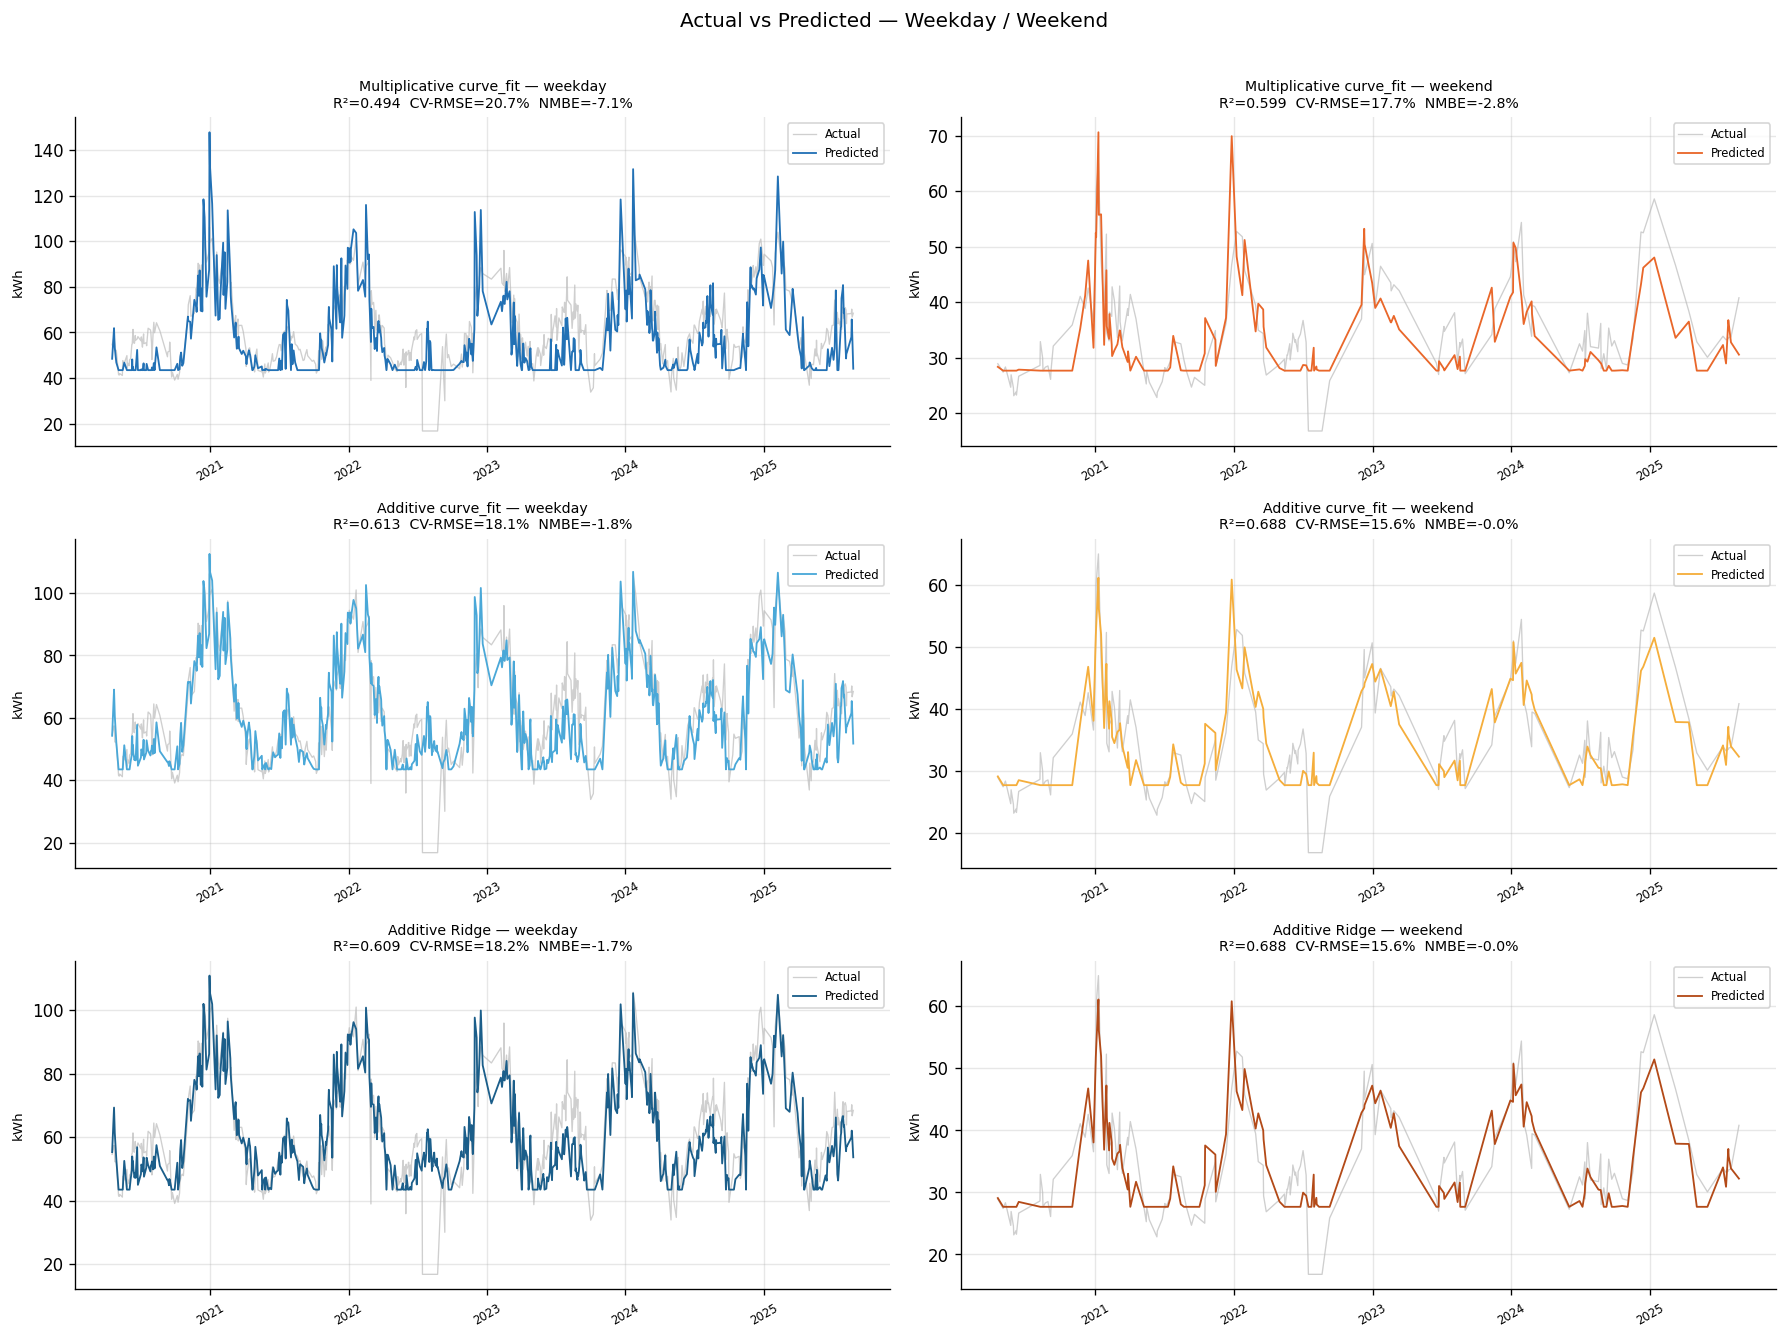

Saved: ecpm_time_series_wd_we.png


In [10]:
# ── Panel 1: Actual vs Predicted time series ─────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=False)
fig.suptitle('Actual vs Predicted — Weekday / Weekend', fontsize=12, y=1.01)

row_models = [
    ('Multiplicative curve_fit', mult_results, 'mult'),
    ('Additive curve_fit',       cf_results,   'cf'),
    ('Additive Ridge',           ridge_results,'ridge'),
]

for row_idx, (model_name, res_dict, key) in enumerate(row_models):
    for col_idx, day_type in enumerate(['weekday','weekend']):
        ax = axes[row_idx, col_idx]
        if day_type not in res_dict:
            ax.set_visible(False); continue
        r = res_dict[day_type]
        col = COLORS[(day_type, key)]
        ax.plot(r['dates'], r['E_actual'], color=COLORS[f'actual_{day_type[:2]}'],
                lw=0.8, alpha=0.7, label='Actual')
        ax.plot(r['dates'], r['E_pred'],   color=col,
                lw=1.1, label='Predicted')
        ax.set_title(
            f"{model_name} — {day_type}\n"
            f"R²={r['R2']:.3f}  CV-RMSE={r['CV_RMSE_pct']:.1f}%  NMBE={r['NMBE_pct']:.1f}%",
            fontsize=8.5
        )
        ax.set_ylabel('kWh', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.tight_layout()
plt.savefig('ecpm_time_series_wd_we.png', bbox_inches='tight')
plt.show()
print('Saved: ecpm_time_series_wd_we.png')

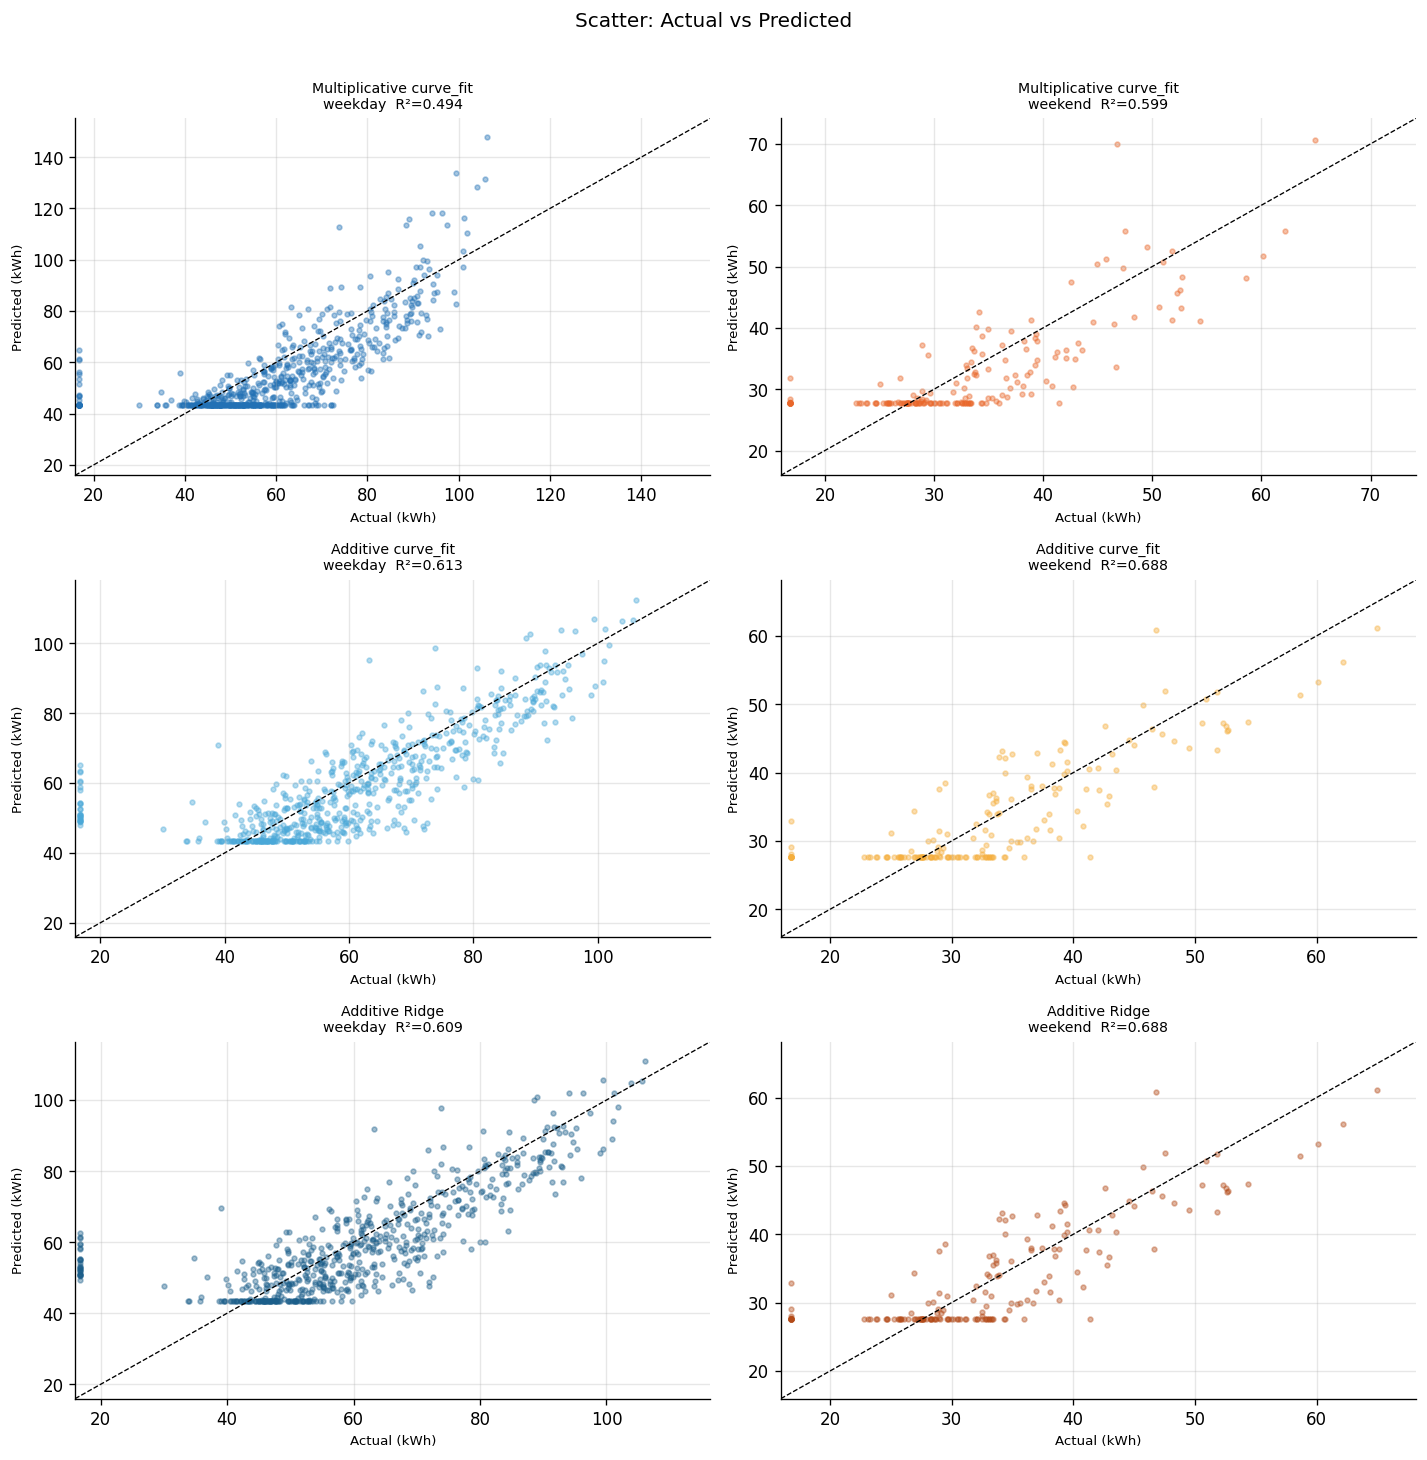

Saved: ecpm_scatter_wd_we.png


In [11]:
# ── Panel 2: Scatter (actual vs predicted) ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Scatter: Actual vs Predicted', fontsize=12, y=1.01)

for row_idx, (model_name, res_dict, key) in enumerate(row_models):
    for col_idx, day_type in enumerate(['weekday','weekend']):
        ax = axes[row_idx, col_idx]
        if day_type not in res_dict:
            ax.set_visible(False); continue
        r   = res_dict[day_type]
        col = COLORS[(day_type, key)]
        ax.scatter(r['E_actual'], r['E_pred'], s=8, alpha=0.4, color=col)
        lim = [min(r['E_actual'].min(), r['E_pred'].min()) * 0.95,
               max(r['E_actual'].max(), r['E_pred'].max()) * 1.05]
        ax.plot(lim, lim, 'k--', lw=0.8)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('Actual (kWh)', fontsize=8)
        ax.set_ylabel('Predicted (kWh)', fontsize=8)
        ax.set_title(f'{model_name}\n{day_type}  R²={r["R2"]:.3f}', fontsize=8.5)

plt.tight_layout()
plt.savefig('ecpm_scatter_wd_we.png', bbox_inches='tight')
plt.show()
print('Saved: ecpm_scatter_wd_we.png')

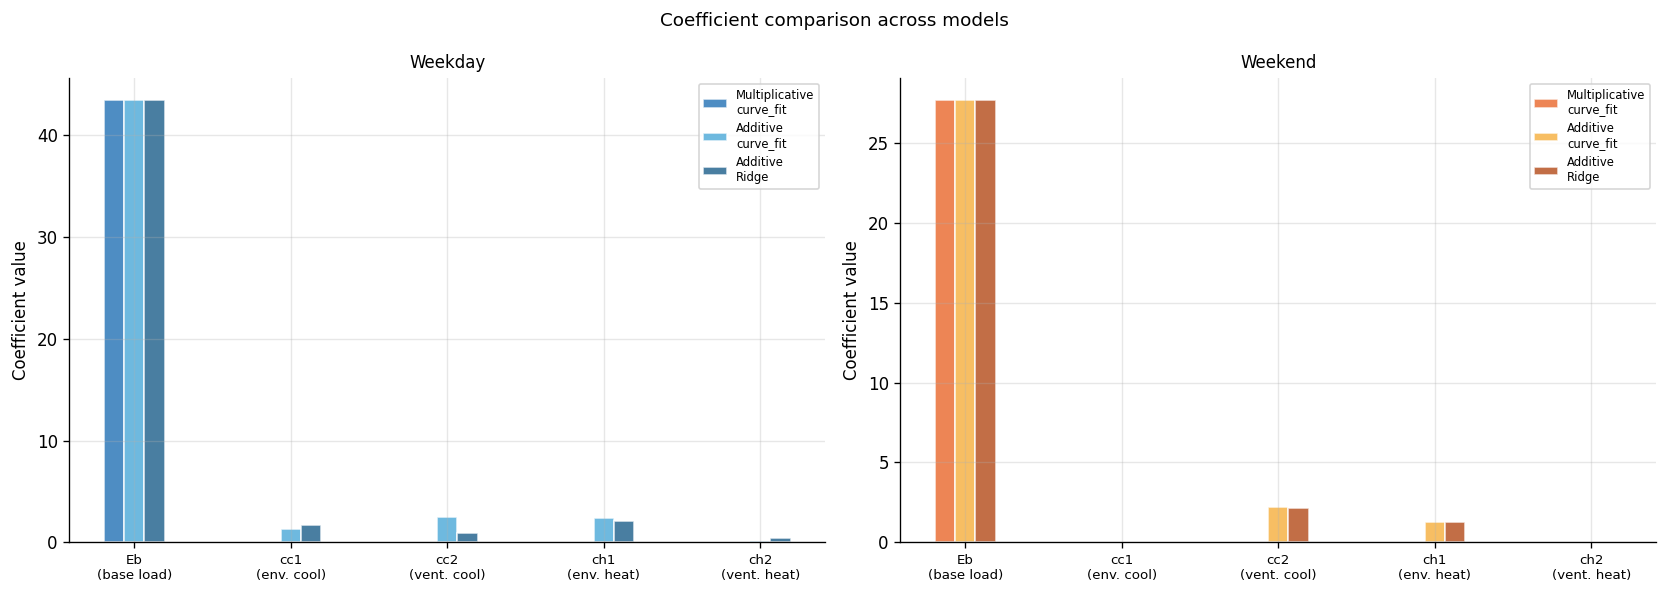

Saved: ecpm_coefficients_wd_we.png


In [12]:
# ── Panel 3: Coefficient comparison bar chart ────────────────────────────────
coeff_names = ['Eb', 'cc1', 'cc2', 'ch1', 'ch2']
coeff_labels = ['Eb\n(base load)', 'cc1\n(env. cool)', 'cc2\n(vent. cool)',
                'ch1\n(env. heat)', 'ch2\n(vent. heat)']
x = np.arange(len(coeff_names))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coefficient comparison across models', fontsize=11)

for ax, day_type in zip(axes, ['weekday', 'weekend']):
    models_to_plot = [
        ('Multiplicative\ncurve_fit', mult_results,  'mult',  ['Eb','cc','ch']),
        ('Additive\ncurve_fit',       cf_results,    'cf',    coeff_names),
        ('Additive\nRidge',           ridge_results, 'ridge', coeff_names),
    ]
    offsets = [-width, 0, width]

    for offset, (mname, res, key, cnames) in zip(offsets, models_to_plot):
        if day_type not in res: continue
        r = res[day_type]
        # map coefficient names → values (nan for missing)
        vals = [r.get(c, float('nan')) for c in coeff_names]
        col  = COLORS[(day_type, key)]
        bars = ax.bar(x + offset, vals, width, label=mname,
                      color=col, alpha=0.8, edgecolor='white')

    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(coeff_labels, fontsize=8)
    ax.set_title(day_type.capitalize(), fontsize=10)
    ax.set_ylabel('Coefficient value')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('ecpm_coefficients_wd_we.png', bbox_inches='tight')
plt.show()
print('Saved: ecpm_coefficients_wd_we.png')

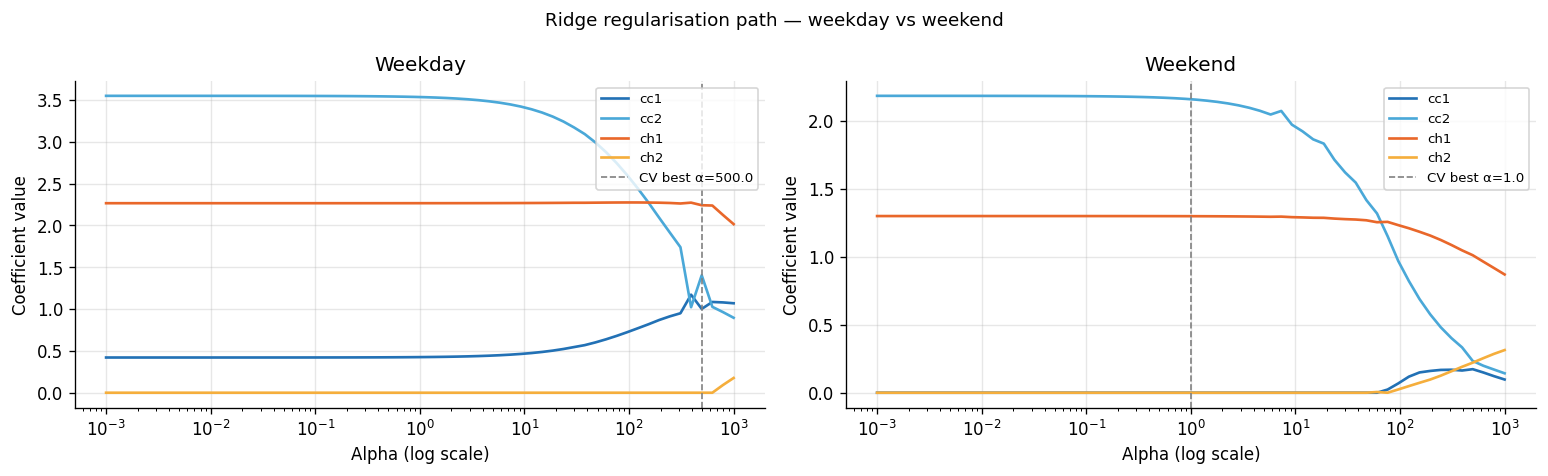

Saved: ridge_path_wd_we.png


In [13]:
# ── Panel 4: Ridge regularisation path per day type ──────────────────────────
alpha_vals = np.logspace(-3, 3, 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Ridge regularisation path — weekday vs weekend', fontsize=11)

for ax, day_type in zip(axes, ['weekday','weekend']):
    if day_type not in ridge_results: continue
    X_r = ridge_results[day_type]['X']
    E_r = ridge_results[day_type]['E_actual']
    best_a = ridge_results[day_type]['alpha']

    paths = {'cc1':[], 'cc2':[], 'ch1':[], 'ch2':[]}
    r2_path = []
    for a in alpha_vals:
        m = Ridge(alpha=a, fit_intercept=True, positive=True)
        m.fit(X_r, E_r)
        for k, v in zip(['cc1','cc2','ch1','ch2'], m.coef_):
            paths[k].append(v)
        r2_path.append(r2_score(E_r, m.predict(X_r)))

    c_map = {'cc1':'#2271B5','cc2':'#4AA8D8','ch1':'#E9672A','ch2':'#F5AE3C'}
    for k, path in paths.items():
        ax.semilogx(alpha_vals, path, label=k, color=c_map[k], lw=1.6)
    ax.axvline(best_a, ls='--', color='gray', lw=1, label=f'CV best α={best_a}')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(day_type.capitalize())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ridge_path_wd_we.png', bbox_inches='tight')
plt.show()
print('Saved: ridge_path_wd_we.png')

## 7 · Per-year × day-type analysis loop

In [14]:
# Only loop over (year, day_type) pairs that exist in cp_params
loop_pairs = cp[cp['year'] != 'all'][['year','day_type']].drop_duplicates()

records = []

for _, row in loop_pairs.iterrows():
    yr       = row['year']
    day_type = row['day_type']
    Tc_l, Th_l, Eb_l = get_cp(yr, day_type)

    sub = get_subset(df, yr, day_type)
    if len(sub) < 15:
        print(f'  {yr}/{day_type}: skipped ({len(sub)} rows)')
        continue

    E_l     = sub['electricity_kWh'].values
    T_ext_l = sub['temp_external'].values
    T_int_l = sub['temp_internal'].values
    base_rec = dict(year=int(yr), day_type=day_type, n=len(E_l),
                    Tc=Tc_l, Th=Th_l, Eb=Eb_l)

    # ── A: Multiplicative curve_fit — Eb fixed ──────────────────────────────
    def _mult(X, cc, ch, _Tc=Tc_l, _Th=Th_l, _Eb=Eb_l):
        te, ti = X
        return _Eb + cc*rplus(te-_Tc)*rplus(te-ti) + ch*rplus(_Th-te)*rplus(ti-te)
    try:
        po, _ = curve_fit(_mult, (T_ext_l, T_int_l), E_l,
                          p0=[5, 2], bounds=([0]*2, [np.inf]*2),
                          method='trf', maxfev=10000)
        Ec_l = po[0] * rplus(T_ext_l - Tc_l) * rplus(T_ext_l - T_int_l)
        Eh_l = po[1] * rplus(Th_l - T_ext_l) * rplus(T_int_l - T_ext_l)
        m    = compute_metrics(E_l, _mult((T_ext_l, T_int_l), *po), 2)
        comp = compute_component_metrics(E_l, Eb_l, Ec_l, Eh_l, T_ext_l, Tc_l, Th_l)
        records.append({**base_rec, 'model': 'Mult_curveFit',
                        'cc': po[0], 'ch': po[1], **m, **comp})
    except Exception as e:
        print(f'  {yr}/{day_type} Mult failed: {e}')

    # ── B: Additive curve_fit — Eb fixed ────────────────────────────────────
    def _add(X, cc1, cc2, ch1, ch2, _Tc=Tc_l, _Th=Th_l, _Eb=Eb_l):
        te, ti = X
        tc_ = (te > _Tc).astype(float)
        th_ = (te < _Th).astype(float)
        return (_Eb + cc1*rplus(te-_Tc) + cc2*rplus(te-ti)*tc_
                    + ch1*rplus(_Th-te) + ch2*rplus(ti-te)*th_)
    try:
        po, _ = curve_fit(_add, (T_ext_l, T_int_l), E_l,
                          p0=[30, 20, 2, 50], bounds=([0]*4, [np.inf]*4),
                          method='trf', maxfev=10000)
        tc_ = (T_ext_l > Tc_l).astype(float)
        th_ = (T_ext_l < Th_l).astype(float)
        Ec_l = po[0]*rplus(T_ext_l - Tc_l) + po[1]*rplus(T_ext_l - T_int_l)*tc_
        Eh_l = po[2]*rplus(Th_l - T_ext_l) + po[3]*rplus(T_int_l - T_ext_l)*th_
        m    = compute_metrics(E_l, _add((T_ext_l, T_int_l), *po), 4)
        comp = compute_component_metrics(E_l, Eb_l, Ec_l, Eh_l, T_ext_l, Tc_l, Th_l)
        records.append({**base_rec, 'model': 'Add_curveFit',
                        'cc1': po[0], 'cc2': po[1], 'ch1': po[2], 'ch2': po[3],
                        **m, **comp})
    except Exception as e:
        print(f'  {yr}/{day_type} Add curveFit failed: {e}')

    # ── C: Additive Ridge — Eb fixed ────────────────────────────────────────
    try:
        tc_ = (T_ext_l > Tc_l).astype(float)
        th_ = (T_ext_l < Th_l).astype(float)
        Xl  = np.column_stack([
            rplus(T_ext_l - Tc_l),
            rplus(T_ext_l - T_int_l) * tc_,
            rplus(Th_l - T_ext_l),
            rplus(T_int_l - T_ext_l) * th_
        ])
        E_res_l = E_l - Eb_l
        n_cv = max(2, min(5, len(E_l) // 15))
        rcv  = RidgeCV(alphas=ALPHAS, fit_intercept=False, scoring='r2', cv=n_cv)
        rcv.fit(Xl, E_res_l)
        rfin = Ridge(alpha=rcv.alpha_, fit_intercept=False, positive=True)
        rfin.fit(Xl, E_res_l)
        E_pred_l = Eb_l + rfin.predict(Xl)
        Ec_l = rfin.coef_[0]*rplus(T_ext_l - Tc_l) + rfin.coef_[1]*rplus(T_ext_l - T_int_l)*tc_
        Eh_l = rfin.coef_[2]*rplus(Th_l - T_ext_l) + rfin.coef_[3]*rplus(T_int_l - T_ext_l)*th_
        m    = compute_metrics(E_l, E_pred_l, 4)
        comp = compute_component_metrics(E_l, Eb_l, Ec_l, Eh_l, T_ext_l, Tc_l, Th_l)
        records.append({**base_rec, 'model': 'Add_Ridge', 'alpha': rcv.alpha_,
                        'cc1': rfin.coef_[0], 'cc2': rfin.coef_[1],
                        'ch1': rfin.coef_[2], 'ch2': rfin.coef_[3],
                        **m, **comp})
    except Exception as e:
        print(f'  {yr}/{day_type} Ridge failed: {e}')

results_df = pd.DataFrame(records)
print(f'\nTotal fits completed: {len(records)}')
display(results_df[['year','day_type','model','n','Tc','Th','Eb',
                     'R2','CV_RMSE_pct','NMBE_pct',
                     'n_Ec','R2_Ec','CV_RMSE_Ec',
                     'n_Eh','R2_Eh','CV_RMSE_Eh']]
        .sort_values(['year','day_type','model'])
        .round(3))

  2025/weekend: skipped (11 rows)

Total fits completed: 33


,year,day_type,model,n,Tc,Th,Eb,R2,CV_RMSE_pct,NMBE_pct,n_Ec,R2_Ec,CV_RMSE_Ec,n_Eh,R2_Eh,CV_RMSE_Eh
2,2020,weekday,Add_Ridge,86,19.851,15.717,43.522,0.914,8.123,0.003,40,0.592,32.785,34,0.898,21.564
1,2020,weekday,Add_curveFit,86,19.851,15.717,43.522,0.914,8.123,0.000,40,0.592,32.786,34,0.898,21.564
0,2020,weekday,Mult_curveFit,86,19.851,15.717,43.522,0.582,17.875,-9.972,40,-2.749,99.417,34,0.623,41.512
20,2020,weekend,Add_Ridge,24,27.822,18.000,27.220,0.749,9.085,0.439,2,NaN,NaN,7,0.731,30.379
19,2020,weekend,Add_curveFit,24,27.822,18.000,27.220,0.749,9.085,0.440,2,NaN,NaN,7,0.731,30.379
18,2020,weekend,Mult_curveFit,24,27.822,18.000,27.220,0.669,10.437,-1.407,2,NaN,NaN,7,0.440,43.828
5,2021,weekday,Add_Ridge,112,19.279,16.050,43.523,0.905,7.587,0.365,37,0.798,27.597,65,0.866,24.224
4,2021,weekday,Add_curveFit,112,19.279,16.050,43.523,0.905,7.555,-0.052,37,0.809,26.845,65,0.866,24.184
3,2021,weekday,Mult_curveFit,112,19.279,16.050,43.523,0.728,12.813,-5.918,37,-0.732,80.794,65,0.695,36.479
23,2021,weekend,Add_Ridge,46,24.572,17.596,26.268,0.765,14.127,-1.804,8,-0.886,115.748,28,0.639,42.065


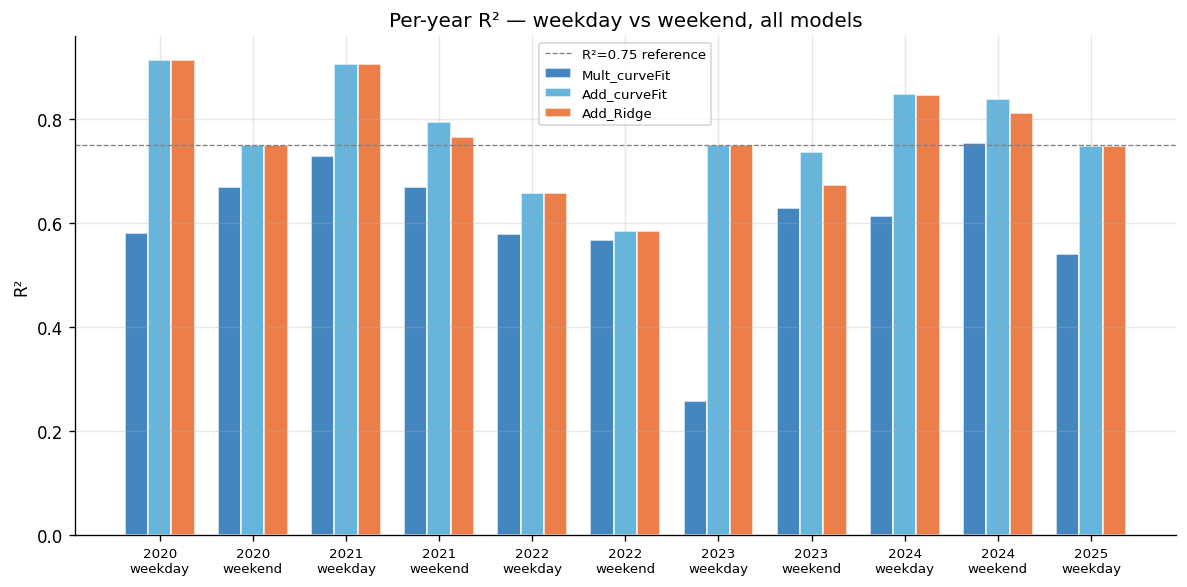

Saved: per_year_r2_wd_we.png


In [15]:
# ── Per-year R² grouped by day_type and model ────────────────────────────────
if not results_df.empty:
    pivot = results_df.pivot_table(
        index=['year','day_type'], columns='model', values='R2'
    ).reset_index()
    pivot['label'] = pivot['year'].astype(str) + '\n' + pivot['day_type']

    model_cols = [c for c in ['Mult_curveFit','Add_curveFit','Add_Ridge'] if c in pivot.columns]
    col_map    = {'Mult_curveFit':'#2271B5','Add_curveFit':'#4AA8D8','Add_Ridge':'#E9672A'}

    x   = np.arange(len(pivot))
    w   = 0.25
    fig, ax = plt.subplots(figsize=(max(10, len(pivot)*0.9), 5))

    for i, mc in enumerate(model_cols):
        if mc in pivot.columns:
            ax.bar(x + (i - 1)*w, pivot[mc], w, label=mc,
                   color=col_map[mc], alpha=0.85, edgecolor='white')

    ax.axhline(0.75, ls='--', color='gray', lw=0.8, label='R²=0.75 reference')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot['label'], fontsize=8)
    ax.set_ylabel('R²')
    ax.set_title('Per-year R² — weekday vs weekend, all models')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('per_year_r2_wd_we.png', bbox_inches='tight')
    plt.show()
    print('Saved: per_year_r2_wd_we.png')

## 8 · Summary table and export

In [16]:
# ── All-years summary table ──────────────────────────────────────────────────
COMP_COLS = ['n_Ec','R2_Ec','RMSE_Ec','CV_RMSE_Ec','NMBE_Ec',
             'n_Eh','R2_Eh','RMSE_Eh','CV_RMSE_Eh','NMBE_Eh',
             'n_deadband']

all_rows = []

for day_type in ['weekday','weekend']:
    for mname, res, key in row_models:
        if day_type not in res: continue
        r = res[day_type]
        row_d = dict(
            year='all', day_type=day_type, model=mname,
            n=len(r['E_actual']),
            Tc=r['Tc'], Th=r['Th'],
            Eb=r.get('Eb'), cc=r.get('cc'), cc1=r.get('cc1'), cc2=r.get('cc2'),
            ch=r.get('ch'), ch1=r.get('ch1'), ch2=r.get('ch2'),
            R2=r['R2'], Adj_R2=r['Adj_R2'],
            CV_RMSE_pct=r['CV_RMSE_pct'], NMBE_pct=r['NMBE_pct'], RMSE=r['RMSE'],
            **{c: r.get(c, np.nan) for c in COMP_COLS}
        )
        all_rows.append(row_d)

all_df = pd.DataFrame(all_rows)

# ── Overall metrics display ──────────────────────────────────────────────────
print('=== Overall model metrics (year=all) ===')
display(all_df[['day_type','model','n','Tc','Th','Eb','cc1','cc2','ch1','ch2',
                'R2','CV_RMSE_pct','NMBE_pct']].round(4))

# ── Component metrics display ────────────────────────────────────────────────
print('\n=== Component metrics — Ec (cooling) and Eh (heating) (year=all) ===')
print('Note: n_Ec + n_Eh + n_deadband = n  (deadband = days where Th ≤ T_ext ≤ Tc)')
display(all_df[['day_type','model',
                'n_Ec','R2_Ec','RMSE_Ec','CV_RMSE_Ec','NMBE_Ec',
                'n_Eh','R2_Eh','RMSE_Eh','CV_RMSE_Eh','NMBE_Eh',
                'n_deadband']].round(4))

# ── Save outputs ─────────────────────────────────────────────────────────────
all_df.to_csv('ecpm_all_years_wd_we.csv', index=False)
print('\nSaved: ecpm_all_years_wd_we.csv')

if not results_df.empty:
    results_df.to_csv('ecpm_per_year_wd_we.csv', index=False)
    print('Saved: ecpm_per_year_wd_we.csv')

# ── Standalone component CSV (easier to read) ────────────────────────────────
comp_cols_export = ['year','day_type','model','n','Tc','Th','Eb',
                    'R2',
                    'n_Ec','R2_Ec','RMSE_Ec','CV_RMSE_Ec','NMBE_Ec',
                    'n_Eh','R2_Eh','RMSE_Eh','CV_RMSE_Eh','NMBE_Eh',
                    'n_deadband']

all_comp = all_df[[c for c in comp_cols_export if c in all_df.columns]].copy()

if not results_df.empty:
    yr_comp = results_df[[c for c in comp_cols_export if c in results_df.columns]].copy()
    combined_comp = pd.concat([all_comp, yr_comp], ignore_index=True)
else:
    combined_comp = all_comp

combined_comp.to_csv('ecpm_component_metrics_Ec_Eh.csv', index=False)
print('Saved: ecpm_component_metrics_Ec_Eh.csv  ← Ec / Eh metrics for all years & models')
print('\nColumn note: n_Ec + n_Eh + n_deadband = n  (deadband days have Th ≤ T_ext ≤ Tc)')


=== Overall model metrics (year=all) ===


,day_type,model,n,Tc,Th,Eb,cc1,cc2,ch1,ch2,R2,CV_RMSE_pct,NMBE_pct
0,weekday,Multiplicative curve_fit,631,21.5867,16.9547,43.4741,NaN,NaN,NaN,NaN,0.4941,20.6826,-7.0896
1,weekday,Additive curve_fit,631,21.5867,16.9547,43.4741,1.3050,2.4530,2.4032,0.1170,0.6135,18.0787,-1.8263
2,weekday,Additive Ridge,631,21.5867,16.9547,43.4741,1.6723,0.8853,2.0763,0.3862,0.6086,18.1937,-1.6654
3,weekend,Multiplicative curve_fit,171,25.7050,14.0277,27.6754,NaN,NaN,NaN,NaN,0.5994,17.6574,-2.8186
4,weekend,Additive curve_fit,171,25.7050,14.0277,27.6754,0.0000,2.1846,1.2996,0.0000,0.6881,15.5796,-0.0072
5,weekend,Additive Ridge,171,25.7050,14.0277,27.6754,0.0000,2.1661,1.2996,0.0000,0.6881,15.5796,-0.0221



=== Component metrics — Ec (cooling) and Eh (heating) (year=all) ===
Note: n_Ec + n_Eh + n_deadband = n  (deadband = days where Th ≤ T_ext ≤ Tc)


,day_type,model,n_Ec,R2_Ec,RMSE_Ec,CV_RMSE_Ec,NMBE_Ec,n_Eh,R2_Eh,RMSE_Eh,CV_RMSE_Eh,NMBE_Eh,n_deadband
0,weekday,Multiplicative curve_fit,234,-0.8053,12.6591,85.5652,-58.4183,303,0.6159,10.3427,40.0772,-14.8510,94
1,weekday,Additive curve_fit,234,-0.0736,9.7621,65.9839,-33.8157,303,0.8188,7.1045,27.5296,-0.0032,94
2,weekday,Additive Ridge,234,-0.0438,9.6255,65.0607,-33.8985,303,0.8164,7.1499,27.7055,0.8206,94
3,weekend,Multiplicative curve_fit,49,-0.3976,4.0664,110.9171,-62.7401,69,0.4199,6.5447,47.4795,-13.9356,53
4,weekend,Additive curve_fit,49,0.0118,3.4194,93.2693,-43.1513,69,0.6483,5.0961,36.9703,-0.5473,53
5,weekend,Additive Ridge,49,0.0094,3.4235,93.3802,-43.6346,69,0.6483,5.0961,36.9703,-0.5468,53



Saved: ecpm_all_years_wd_we.csv
Saved: ecpm_per_year_wd_we.csv
Saved: ecpm_component_metrics_Ec_Eh.csv  ← Ec / Eh metrics for all years & models

Column note: n_Ec + n_Eh + n_deadband = n  (deadband days have Th ≤ T_ext ≤ Tc)


## 9 · Cooling & Heating Component Metrics — Visualisation

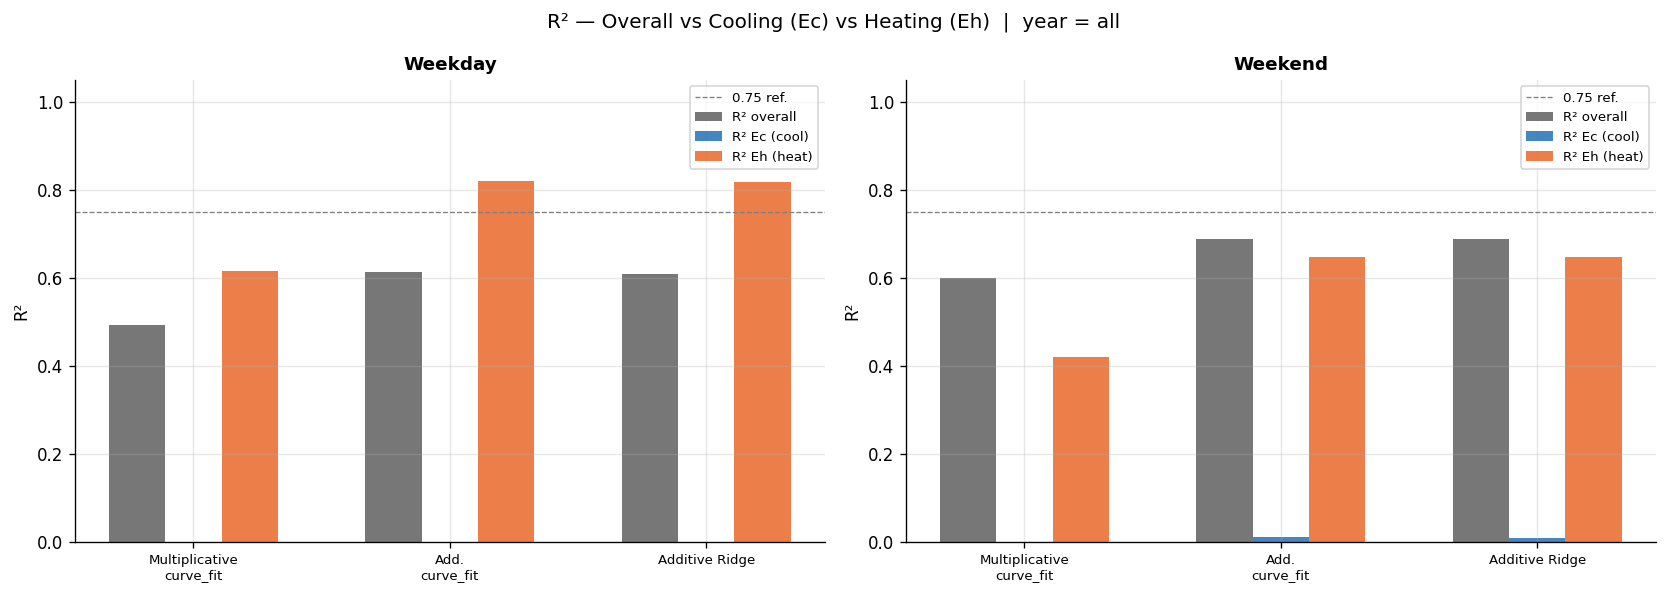

Saved: ecpm_r2_components_wd_we.png


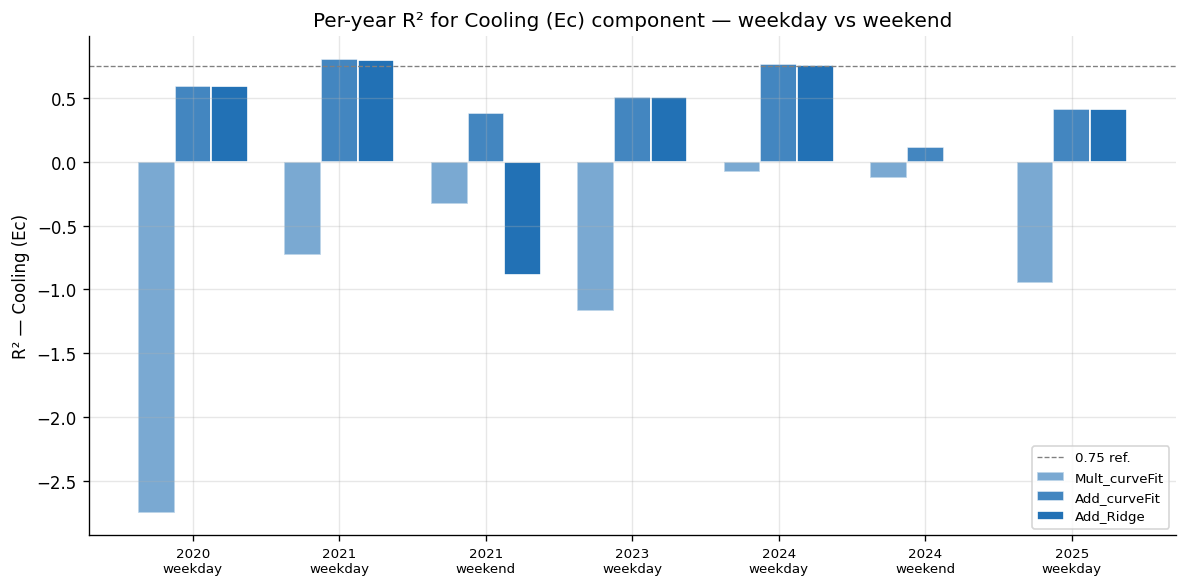

Saved: per_year_r2_r2_ec_wd_we.png


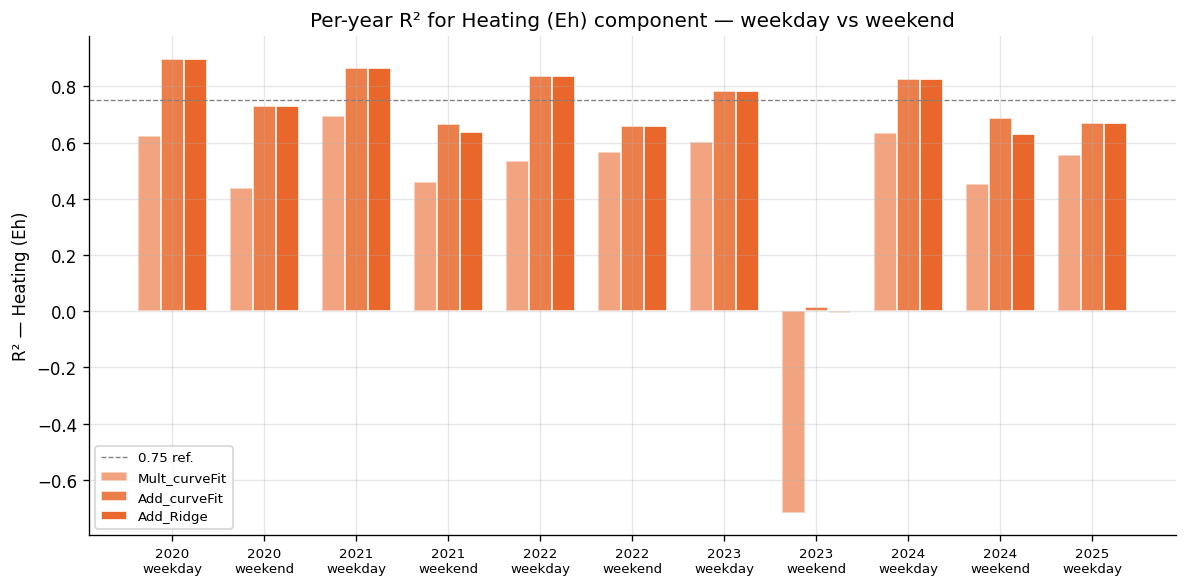

Saved: per_year_r2_r2_eh_wd_we.png


In [17]:
# ── R² comparison: overall vs Ec vs Eh, per day_type × model (year=all) ──────
plot_df = all_df[all_df['year'] == 'all'].copy()
models_order = ['Multiplicative curve_fit', 'Additive curve_fit', 'Additive Ridge']
labels = [m.replace(' curve_fit', '\ncurve_fit').replace('Additive\n', 'Add.\n') for m in models_order]
x = np.arange(len(models_order))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('R² — Overall vs Cooling (Ec) vs Heating (Eh)  |  year = all', fontsize=12)

for ax, day_type in zip(axes, ['weekday', 'weekend']):
    sub = plot_df[plot_df['day_type'] == day_type].set_index('model')
    r2_all = [sub.loc[m, 'R2']    if m in sub.index else np.nan for m in models_order]
    r2_ec  = [sub.loc[m, 'R2_Ec'] if m in sub.index else np.nan for m in models_order]
    r2_eh  = [sub.loc[m, 'R2_Eh'] if m in sub.index else np.nan for m in models_order]

    ax.bar(x - w,   r2_all, w, label='R² overall', color='#555555', alpha=0.8)
    ax.bar(x,       r2_ec,  w, label='R² Ec (cool)', color='#2271B5', alpha=0.85)
    ax.bar(x + w,   r2_eh,  w, label='R² Eh (heat)', color='#E9672A', alpha=0.85)

    ax.axhline(0.75, ls='--', color='gray', lw=0.8, label='0.75 ref.')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('R²')
    ax.set_title(day_type.capitalize(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ecpm_r2_components_wd_we.png', bbox_inches='tight')
plt.show()
print('Saved: ecpm_r2_components_wd_we.png')

# ── Per-year R²_Ec and R²_Eh bar chart ───────────────────────────────────────
if not results_df.empty:
    for comp_tag, color in [('R2_Ec', '#2271B5'), ('R2_Eh', '#E9672A')]:
        label_name = 'Cooling (Ec)' if comp_tag == 'R2_Ec' else 'Heating (Eh)'
        pivot = results_df.pivot_table(
            index=['year','day_type'], columns='model', values=comp_tag
        ).reset_index()
        pivot['label'] = pivot['year'].astype(str) + '\n' + pivot['day_type']

        model_cols = [c for c in ['Mult_curveFit','Add_curveFit','Add_Ridge'] if c in pivot.columns]
        shade_map  = {'Mult_curveFit': 0.6, 'Add_curveFit': 0.85, 'Add_Ridge': 1.0}

        xp = np.arange(len(pivot))
        wp = 0.25
        fig, ax = plt.subplots(figsize=(max(10, len(pivot)*0.9), 5))

        for i, mc in enumerate(model_cols):
            vals = pivot[mc].values
            ax.bar(xp + (i-1)*wp, vals, wp, label=mc,
                   color=color, alpha=shade_map[mc], edgecolor='white')

        ax.axhline(0.75, ls='--', color='gray', lw=0.8, label='0.75 ref.')
        ax.set_xticks(xp)
        ax.set_xticklabels(pivot['label'], fontsize=8)
        ax.set_ylabel(f'R² — {label_name}')
        ax.set_title(f'Per-year R² for {label_name} component — weekday vs weekend')
        ax.legend(fontsize=8)
        plt.tight_layout()
        fname = f'per_year_r2_{comp_tag.lower()}_wd_we.png'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')